# Likelihood approximation: $s=1$, $r=m=100$

This notebook compares **ResTGP(Full)**, **ResTGP(PP)** and **sSGV (Vecchia)** with the **Exact GP**. It produces three figures against dimension: log likelihood, relative log-likelihood error, and approximation time. Each figure has one row of panels, with one panel per sample size.

| Setting | Value |
|---|---|
| Sample sizes | 2,000, 5,000, 10,000 |
| Dimensions | 2, 5, 10, 20 |
| Locations | Latin hypercube on $[0,1]^d$, clipped to $[10^{-4},1-10^{-4}]$ |
| True GP | Mean 0, process variance 1, Matérn smoothness $\nu=1.5$, nugget variance 0.1 |
| Coordinate ranges | $\rho_j=4^{(j-1)/(d-1)}$, from 1 to 4 |
| Full and PP | Middle cuts, sequential maximin knots, budget $r=100$ per node |
| PP | Stratified resampling, `temper_alpha = 1`, `prior_rho = 0.05`, `prior_beta = 0` |
| PP depth and particles | $H=\lceil\log_2(n/r)\rceil$, $100H$ particles, three algorithm seeds |
| Vecchia | Maximin ordering and nearest predecessors in the original coordinates, $m=r=100$ |
| Production base seed | 2023 |

For $t_{ij}=\{\sum_k((x_{ik}-x_{jk})/\rho_k)^2\}^{1/2}$, the generating covariance is

$$C_{ij}=(1+t_{ij})e^{-t_{ij}}+0.1\,\mathbf{1}\{i=j\}.$$

The code draws $z\sim N(0,I)$ and sets $y=U^\top z$, where $C=U^\top U$. All methods use the same observations and evaluate the likelihood at the true covariance parameters; no parameters are fitted. The two budgets share data seeds and exact-data caches. PP seeds change only its SMC algorithm. Full splits until each leaf has at most $r$ observations; the depth formula above is PP's maximum depth.


## Reproduce these figures

1. Use R with `ResTree`, `GpGp` and `DiceDesign` for simulation, and `dplyr`, `ggplot2` and `scales` for plotting. Open this notebook with an R kernel (`IRkernel`). The saved production results used **R 4.4.3, ResTree 0.1.8, GpGp 0.5.1 and DiceDesign 1.10**, with OpenBLAS 0.3.27 on Linux; use these versions when reproducing the numerical results. The code records the installed versions in `output/session_cluster_s1_r100.txt`.
2. From the **Loglik_approx** folder, run the matching entry point below on a machine or cluster allocation with the required resources. The original production allocation used 10 CPUs and 64 GB of memory. The exact-GP memory guard remains 50 GB.

```bash
cd /path/to/Loglik_approx
export RESTREE_NCORES=10 OMP_NUM_THREADS=10
export OPENBLAS_NUM_THREADS=10 MKL_NUM_THREADS=10
export BLIS_NUM_THREADS=10 VECLIB_MAXIMUM_THREADS=10
export OMP_DYNAMIC=FALSE OMP_PLACES=cores OMP_PROC_BIND=spread
Rscript R/01_run_cluster_r100.R
```

This evaluates all 12 combinations of sample size and dimension: one Full, one Vecchia and three PP evaluations per data set. It writes `output/N_s1_r100.rds`, the matching CSV, exact-data caches, summary tables and a session record. Each evaluation is saved immediately; rerunning the same command resumes completed work. The other budget uses `R/01_run_cluster.R`.

3. If the simulation ran on a cluster, copy `output/N_s1_r100.rds` back into this folder's `output/` directory. If the result file already exists locally, skip the simulation. The code-only folder does not include these result files; embedded plots are previews from the saved production results.
4. Set the notebook's working directory to **Loglik_approx**, edit the selection below if needed, then **Restart Kernel and Run All**. Every plot is displayed and exported to `figure/` as a 12 × 4-inch PDF. Rerun all cells after changing the data file, budget, dimensions, sample sizes or PP seed.

| Figure | Saved file |
|---|---|
| Log likelihood | `figure/Loglik_vs_d_across_n_r100_s1.pdf` |
| Relative log-likelihood error | `figure/Loglik_percentage_vs_d_across_n_r100_s1.pdf` |
| Approximation time | `figure/Timing_vs_d_across_n_r100_s1.pdf` |

The numerical entry points are `R/01_run_cluster.R` and `R/01_run_cluster_r100.R`; their grid settings are at the top. `R/api_contract.R` holds the method defaults. `R/01_run_study.R` coordinates the run, and `R/helpers/` groups data generation, exact likelihood, approximation methods, timing and summaries. This release contains only the two production runs and their shared helpers. Both use the settings above; no preliminary experiments are required. See `README.md` for the production software versions and run commands.


## 1. Select data and labels

Keep one nugget value for this panel layout. The selected budget must be present in `data_file`. Edit the titles, labels, methods and PDF names here; a title of `NULL` leaves it blank.

In [1]:
library(dplyr)
library(ggplot2)

r = 100
data_file = "output/N_s1_r100.rds"
results = readRDS(data_file)

sample_sizes = c(2000, 5000, 10000)
dimensions = c(2, 5, 10, 20)
pp_seed_to_plot = 1
nu_to_plot = 1.5
minimum_range = 1
nugget_values = 0.1
cut_method_to_plot = "middle"
temper_alpha_to_plot = 1
methods = c("ResTGP(Full)", "ResTGP(PP)", "sSGV", "Exact GP")

dimension_label = "d"
likelihood_label = "Log likelihood"
relative_error_label = "Percentage difference"
time_label = "Time (seconds)"
likelihood_title = "Log likelihood against dimension"
relative_error_title = NULL
time_title = NULL
percentage_reference = 0.1

figure_directory = "figure"
figure_width = 12
figure_height = 4
likelihood_file = "Loglik_vs_d_across_n_r100_s1.pdf"
relative_error_file = "Loglik_percentage_vs_d_across_n_r100_s1.pdf"
time_file = "Timing_vs_d_across_n_r100_s1.pdf"
dir.create(figure_directory, recursive = TRUE, showWarnings = FALSE)
options(repr.plot.width = figure_width, repr.plot.height = figure_height)



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




## 2. Inspect and select the recorded settings

The first table shows the available settings. The second shows the rows actually selected, including the knot budget and PP seed.

In [ ]:
results |>
  distinct(n, d, nu, rho_min, rho_max, nugget, knob, cut_method, temper_alpha) |>
  arrange(n, d, knob)

selected = results |>
  filter(
    status == "ok",
    near(nu, .env$nu_to_plot),
    n %in% sample_sizes,
    d %in% dimensions,
    startsWith(regime, "rho_min"),
    near(rho_min, .env$minimum_range),
    nugget %in% nugget_values,
    knob == .env$r,
    cut_method == .env$cut_method_to_plot,
    temper_alpha == .env$temper_alpha_to_plot,
    method_id %in% c("restgp_full", "restgp_pp", "ssgv"),
    method_id != "restgp_pp" | pp_seed == .env$pp_seed_to_plot
  )

# selected |>
#   count(n, d, knob, method, pp_seed, name = "rows")


n,d,nu,rho_min,rho_max,nugget,knob,cut_method,temper_alpha
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
2000,2,1.5,1,4,0.1,100,middle,1
2000,5,1.5,1,4,0.1,100,middle,1
2000,10,1.5,1,4,0.1,100,middle,1
2000,20,1.5,1,4,0.1,100,middle,1
5000,2,1.5,1,4,0.1,100,middle,1
5000,5,1.5,1,4,0.1,100,middle,1
5000,10,1.5,1,4,0.1,100,middle,1
5000,20,1.5,1,4,0.1,100,middle,1
10000,2,1.5,1,4,0.1,100,middle,1


n,d,knob,method,pp_seed,rows
<int>,<int>,<int>,<chr>,<int>,<int>
2000,2,100,ResTGP(Full),NA,1
2000,2,100,ResTGP(PP),1,1
2000,2,100,sSGV,NA,1
2000,5,100,ResTGP(Full),NA,1
2000,5,100,ResTGP(PP),1,1
2000,5,100,sSGV,NA,1
2000,10,100,ResTGP(Full),NA,1
2000,10,100,ResTGP(PP),1,1
2000,10,100,sSGV,NA,1


## 3. Prepare complete panels

Each likelihood/error panel needs every selected method at every selected dimension. Timing requires only the selected approximation methods and the recorded setup-plus-likelihood timing protocol. Incomplete panels are omitted. The exact likelihood is included once per data setting.

In [3]:
approximate_data = selected |>
  transmute(
    n, d, nugget,
    method = recode(method_id,
      restgp_full = "ResTGP(Full)",
      restgp_pp = "ResTGP(PP)",
      ssgv = "sSGV"
    ),
    loglik,
    relative_error = abs(loglik - exact) / abs(exact),
    time_seconds = if_else(timing_protocol == "elapsed_setup_likelihood_v2",
                           seconds_total, NA_real_)
  )

exact_data = selected |>
  distinct(n, d, nugget, exact) |>
  transmute(n, d, nugget, method = "Exact GP",
            loglik = exact, relative_error = 0, time_seconds = NA_real_)

likelihood_data = bind_rows(approximate_data, exact_data) |>
  filter(method %in% methods) |>
  mutate(method = factor(method, levels = methods)) |>
  group_by(n, nugget) |>
  filter(n_distinct(interaction(d, method)) == length(dimensions) * length(methods)) |>
  ungroup()

timing_methods = setdiff(methods, "Exact GP")
timing_data = approximate_data |>
  filter(method %in% timing_methods, !is.na(time_seconds)) |>
  mutate(method = factor(method, levels = timing_methods)) |>
  group_by(n, nugget) |>
  filter(n_distinct(interaction(d, method)) == length(dimensions) * length(timing_methods)) |>
  ungroup()


## 4. Shared plot appearance

All figures use black lines, fixed method symbols and line types, and a compact bottom legend. Edit this cell to change their common appearance.

In [4]:
plot_style = list(
  scale_colour_manual(values = c(
    "ResTGP(Full)" = "black", "ResTGP(PP)" = "black",
    "sSGV" = "black", "Exact GP" = "black"
  )),
  scale_linetype_manual(values = c(
    "ResTGP(Full)" = "solid", "ResTGP(PP)" = "longdash",
    "sSGV" = "dotted", "Exact GP" = "dashed"
  )),
  scale_shape_manual(values = c(
    "ResTGP(Full)" = 15, "ResTGP(PP)" = 18, "sSGV" = 1, "Exact GP" = 4
  )),
  labs(colour = NULL, linetype = NULL, shape = NULL),
  theme_bw(base_size = 14),
  theme(
    legend.position = "bottom",
    legend.key.width = grid::unit(1.5, "cm"),
    legend.text = element_text(margin = margin(l = 4, r = 15)),
    legend.box.spacing = grid::unit(0, "pt"),
    legend.margin = margin(0, 0, 0, 0)
  )
)


## 5. Log likelihood against dimension

Panels show sample sizes `n = 2000`, `n = 5000`, and `n = 10000` from left to right. Within each panel, dimension changes while the covariance setting, budget and selected PP seed remain fixed. Each line is a method; Exact GP provides the reference. All panels share the vertical scale.

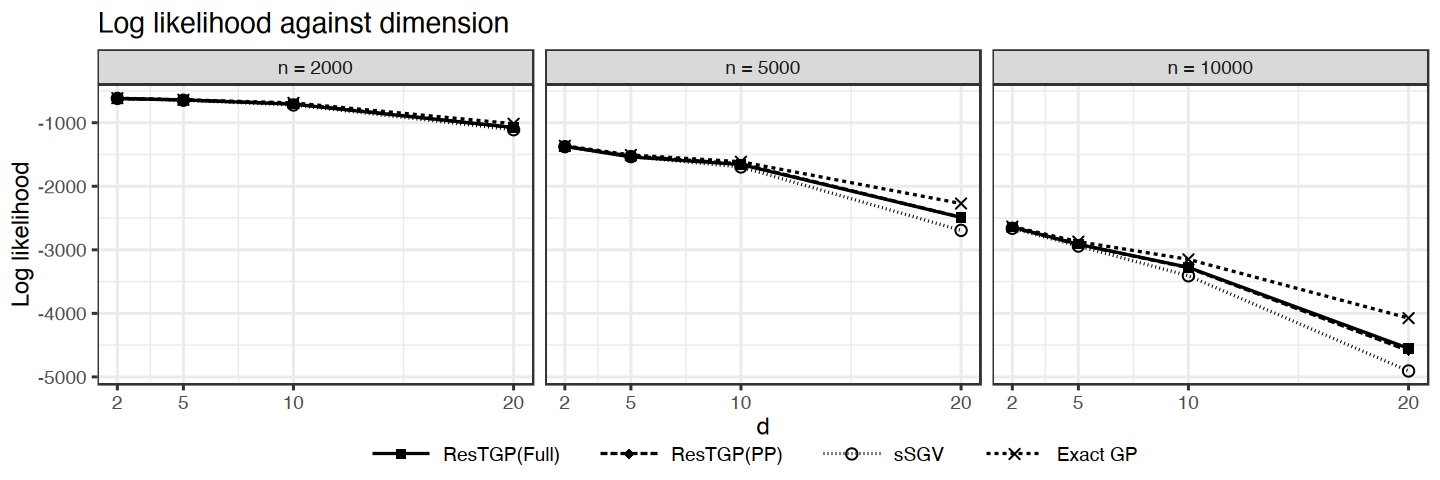

In [5]:
likelihood_plot = ggplot(
  likelihood_data,
  aes(x = d, y = loglik, group = method,
      colour = method, linetype = method, shape = method)
) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2.5) +
  facet_grid(
    ~ n,
    labeller = function(labels) label_both(labels, sep = " = ")
  ) +
  scale_x_continuous(breaks = dimensions) +
  labs(title = likelihood_title, x = dimension_label, y = likelihood_label) +
  plot_style

likelihood_plot

ggsave(
  file.path(figure_directory, likelihood_file),
  likelihood_plot, width = figure_width, height = figure_height
)


## 6. Relative log-likelihood error against dimension

Panels again show sample sizes from left to right, with dimension on the horizontal axis. Curves show `abs(loglik - exact) / abs(exact)`; smaller values mean closer agreement, and Exact GP has zero error. Values are fractions: **0.01 means 1% and 0.1 means 10%**. This is relative error in the log likelihood, not the likelihood itself or a gap divided by sample size. All panels share the vertical scale. The grey dashed reference line marks 0.1 (10%).

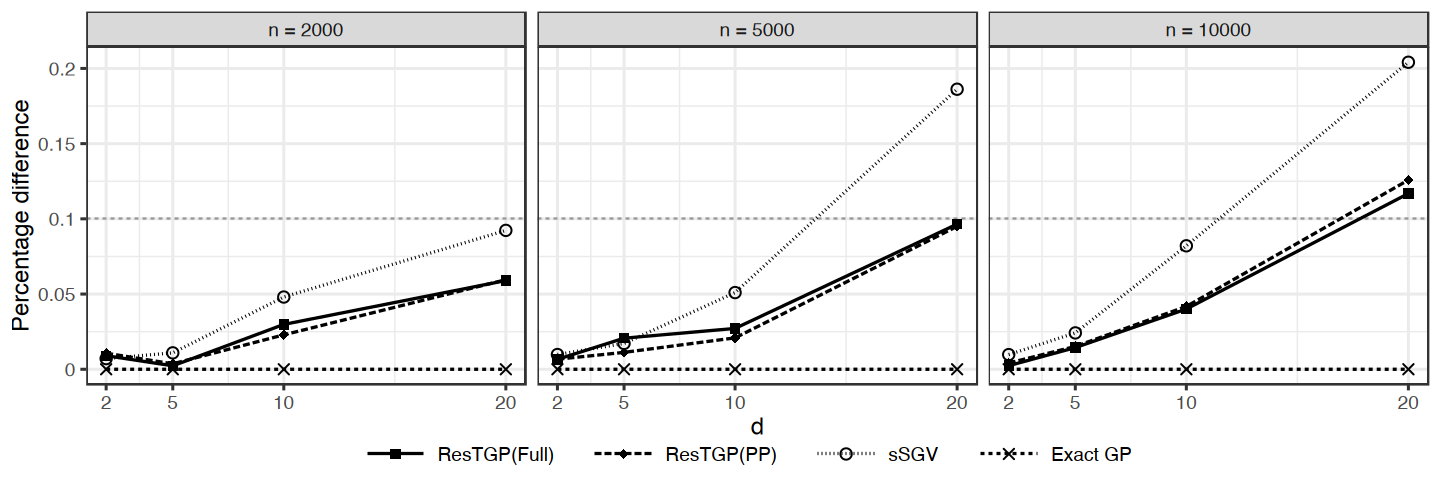

In [6]:
relative_error_plot = ggplot(
  likelihood_data,
  aes(x = d, y = relative_error, group = method,
      colour = method, linetype = method, shape = method)
) +
  geom_hline(yintercept = percentage_reference,
             colour = "grey60", linetype = "dashed", linewidth = 0.5) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2.5) +
  facet_grid(
    ~ n,
    labeller = function(labels) label_both(labels, sep = " = ")
  ) +
  scale_x_continuous(breaks = dimensions) +
  scale_y_continuous(
    breaks = scales::breaks_pretty(n = 8),
    labels = scales::label_number(drop0trailing = TRUE)
  ) +
  labs(title = relative_error_title, x = dimension_label, y = relative_error_label) +
  plot_style

relative_error_plot

ggsave(
  file.path(figure_directory, relative_error_file),
  relative_error_plot, width = figure_width, height = figure_height
)


## 7. Approximation time against dimension

Panels show sample sizes from left to right. Within each panel, dimension changes while all other selected settings remain fixed. Full and PP times include model construction and likelihood evaluation; sSGV includes ordering, neighbor search and likelihood evaluation. Simulation and file I/O are excluded. Exact GP is omitted from timing figures. Its saved timer includes fresh covariance construction, Cholesky factorization and the likelihood solve. The panels share their vertical scale within the single row.

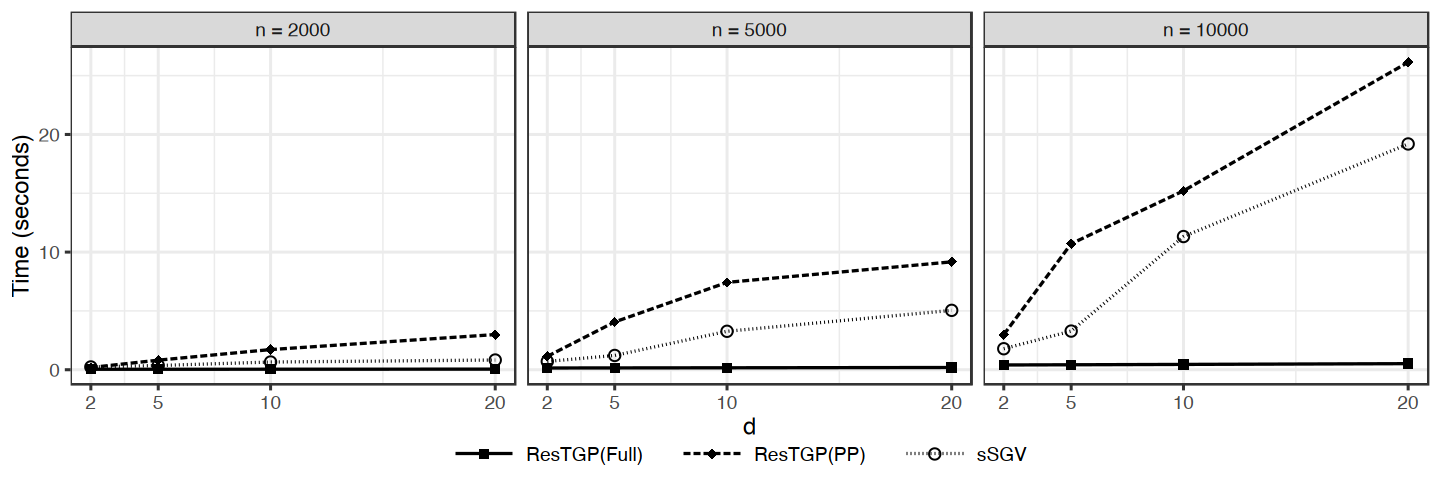

In [7]:
timing_plot = ggplot(
  timing_data,
  aes(x = d, y = time_seconds, group = method,
      colour = method, linetype = method, shape = method)
) +
  geom_line(linewidth = 0.7) +
  geom_point(size = 2.5) +
  facet_grid(
    ~ n,
    labeller = function(labels) label_both(labels, sep = " = "),
    scales = "free_y"
  ) +
  scale_x_continuous(breaks = dimensions) +
  labs(title = time_title, x = dimension_label, y = time_label) +
  plot_style

timing_plot

ggsave(
  file.path(figure_directory, time_file),
  timing_plot, width = figure_width, height = figure_height
)
